# Fig. 1

One sidereal day of the same GSM16 sky behind the same canyon horizon at the
same site, simulated three times with three different beams. Each antenna's
foregrounds get their own uncentered SVD, and each antenna's 21-cm ensemble is
filtered in that antenna's own basis, so every quantity in a panel belongs to
the antenna named in it.

Both curves in every panel are **antenna temperature**, ground pickup
included. The 21-cm models are multiplied by that antenna's beam-weighted
open-sky fraction before filtering, because an isotropic signal reaches the
antenna temperature attenuated by it. They are not sky-referred amplitudes.

**The isotropic beam** is the chromaticity-free reference.

**The Vivaldi feed** is the HERA Phase II design used in isolation without its
dish, which is the antenna EIGSEP's suspended in October 2024.

**Scope.** Zenith pointing, nominal position, GSM16, no noise and no receiver
systematics. 

Data: `beam_comparison.npz`. Full derivation from the raw simulation output:
`mock_analysis/horizon_position/notebooks/beam_comparison.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import eigsep_style as es

In [2]:
d = np.load("beam_comparison.npz", allow_pickle=True)
n_modes = d["n_modes"]                 # foreground modes filtered (x-axis)
order = [str(x) for x in d["order"]]   # panel order, left to right
labels = {b: str(l) for b, l in zip(order, d["labels"])}
t_sys = d["t_sys"]                     # (n_beam, n_time, n_freq) [K] per-beam waterfalls
t_receiver = float(d["t_receiver"])
eta = {b: d["eta"][i] for i, b in enumerate(order)}  # beam-weighted open-sky fraction
C_21 = "0.40"
print(f"{len(order)} antennas, {n_modes[-1]} modes on the axis")

3 antennas, 25 modes on the axis


In [3]:
def resid_curves(dT_axis, Vh, n_modes):
    """Per-row residual RMS over frequency [K] after filtering the leading N modes."""
    n_f = dT_axis.shape[1]
    coeff = dT_axis @ Vh.T
    return np.array([np.sqrt(np.sum(coeff[:, N:] ** 2, axis=1) / n_f)
                     for N in n_modes])


# T21_sky is sky-referenced; each antenna observes it attenuated by its own eta.
m21 = np.load("21cm_models.npz", allow_pickle=True)
assert np.array_equal(m21["freqs_MHz"], d["freqs_MHz"]), "21-cm grid != simulation grid"
T21_sky = m21["T21_sky"]               # (n_model, n_freq) [K], sky-referenced

# Each antenna is filtered in ITS OWN basis: the SVD of its own uncorrected
# antenna-temperature waterfall, receiver subtracted. fg_resid pools the
# per-time-sample residual curves in quadrature; t21_pct is the 5/50/95th
# percentile across models of that antenna's own eta-attenuated ensemble,
# filtered in that same basis.
fg_resid, t21_pct = {}, {}
for i, b in enumerate(order):
    t_ant = t_sys[i] - t_receiver
    _, _, Vh = np.linalg.svd(t_ant, full_matrices=False)
    fg_resid[b] = np.sqrt(np.mean(resid_curves(t_ant, Vh, n_modes) ** 2, axis=1))
    t21_resid = resid_curves(eta[b] * T21_sky, Vh, n_modes)
    t21_pct[b] = np.percentile(t21_resid, [5, 50, 95], axis=1)

In [4]:
def make_figure(n_modes, fg_resid, t21_pct, order, labels, c_21, path):
    """Three panels of the Fig. 1 axes, one per antenna.

    Shared y so the panels can be read against each other; the label sits
    inside each panel rather than as a title, to keep the row compact enough
    for a two-column `figure*`.
    """
    fig, axs = es.figure(cols=2, height_in=2.6833, nrows=1, ncols=3,
                         sharey=True)
    for ax, b in zip(axs, order):
        ax.fill_between(n_modes, t21_pct[b][0], t21_pct[b][2], color=c_21,
                        alpha=0.25, lw=0, zorder=0)
        ax.plot(n_modes, t21_pct[b][1], color=c_21, lw=1.3, ls="--", zorder=1)
        ax.plot(n_modes, fg_resid[b], color="k", lw=1.8, zorder=2)
        ax.set_yscale("log")
        ax.set_xlim(0, n_modes[-1])
        ax.set_ylim(1e-5, 3e3)
        ax.grid(True, which="major", ls=":", lw=0.5, alpha=0.5)
        # Grid under the translucent 21-cm band (fill zorder 0): dimmed there
        # rather than drawn across it. Axis artists default to zorder 1.5; the
        # axes background is drawn before all artists, so -1 still shows.
        ax.xaxis.set_zorder(-1)
        ax.yaxis.set_zorder(-1)
        ax.tick_params(labelsize=7)
        ax.set_xlabel("Foreground modes filtered", fontsize=8)
        ax.text(0.045, 0.94, labels[b], transform=ax.transAxes, va="top",
                fontsize=7.5)
    axs[0].set_ylabel("Residual RMS [K]", fontsize=8)
    # Centre right of the first panel: the white band between the 21 cm
    # ensemble and the foreground curve, which the isotropic residual clears
    # by N ~ 4. Lower right put the box on that residual's descent; upper
    # right collides with the panel label.
    axs[0].legend(
        handles=[
            Line2D([], [], color="k", lw=1.8, label="Beam-weighted foregrounds"),
            Line2D([], [], color=c_21, lw=1.3, ls="--", label="21-cm models"),
        ],
        fontsize=6, loc="center right", framealpha=0.92,
    )
    es.save(fig, path)
    return fig

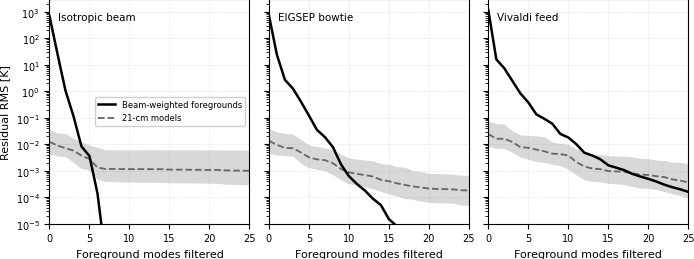

In [5]:
fig = make_figure(n_modes, fg_resid, t21_pct, order, labels, C_21,
                  "beam_comparison.pdf")